# Predictive coding in the latent space

Here's an attempt at implementing a basic predictive coding example in the latent space using NEF-style representations.

In [1]:
import matplotlib.pyplot as plt
import nengo
import numpy as np

First, we need to be able to clamp parts of our model, including controlling the value we're clamping to and whether or not the clamp is active.  Let's implement this just as a PID controller.  For this, I'm just repurposing an existing PID controller implementation, but since everything's linear we don't even need neurons here.  We have an `active` input that controls whether the clamp is active and a `target` input to set the target value.   Note that you do also have to reset the I term integrator when the clamp is not active.

In [2]:
class Clamp(nengo.Network):
    def __init__(self, size_in, Kp=0.5, Kd=0.01, Ki=1):
        super().__init__()
        with self:
            self.target = nengo.Node(None, size_in=size_in)
            self.actual = nengo.Node(None, size_in=size_in)
            self.u = nengo.Node(None, size_in=size_in)

            self.d_target = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.target, self.d_target, synapse=None, transform=1000)
            nengo.Connection(self.target, self.d_target, synapse=0, transform=-1000)
    
        
            self.q_diff = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.target, self.q_diff, synapse=None)
            nengo.Connection(self.actual, self.q_diff, synapse=None, transform=-1)
    
            nengo.Connection(self.q_diff, self.u, transform=Kp, synapse=None)
    
    
            self.dq_diff = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.d_target, self.dq_diff, synapse=None)
            #nengo.Connection(env.dq, dq_diff, synapse=None, transform=-1)
    
            nengo.Connection(self.dq_diff, self.u, transform=Kd, synapse=None)
    
            intq_diff = nengo.Node(lambda t,x: x[1:] if x[0]>0 else x[1:]*0, size_in=size_in+1)

            nengo.Connection(self.target, intq_diff[1:], synapse=None)
            nengo.Connection(self.actual, intq_diff[1:], synapse=None, transform=-1)
            nengo.Connection(intq_diff, intq_diff[1:], synapse=0.1)
            
            nengo.Connection(intq_diff, self.u, transform=Ki, synapse=None)            
            
            self.active=nengo.Node(None, size_in=1)
            self.output = nengo.Node(lambda t,x: x[1:] if x[0]>0 else x[1:]*0, size_in=size_in+1)
            nengo.Connection(self.active, self.output[0], synapse=None)
            nengo.Connection(self.active, intq_diff[0], synapse=None)
            nengo.Connection(self.u, self.output[1:], synapse=None)

Let's make sure that works with a simple sine wave and turn the clamp on and off.

In [3]:
model = nengo.Network()
with model:
    ens = nengo.Ensemble(n_neurons=100, dimensions=1)
    clamp = Clamp(size_in=1)
    nengo.Connection(ens, clamp.actual)
    nengo.Connection(clamp.output, ens)

    stim_active = nengo.Node(lambda t: 1 if t%2<1 else -1)
    stim_target = nengo.Node(lambda t: np.sin(t))
    nengo.Connection(stim_active, clamp.active)
    nengo.Connection(stim_target, clamp.target)

    p_target = nengo.Probe(stim_target)
    p_active = nengo.Probe(stim_active)
    p_ens = nengo.Probe(ens, synapse=0.01)

sim = nengo.Simulator(model)
with sim:
    sim.run(10)

C:\Users\terry\anaconda3\Lib\site-packages\nengo\cache.py:624: UserWarning: Decoder cache could not acquire lock and was deactivated.
  warnings.warn("Decoder cache could not acquire lock and was deactivated.")


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

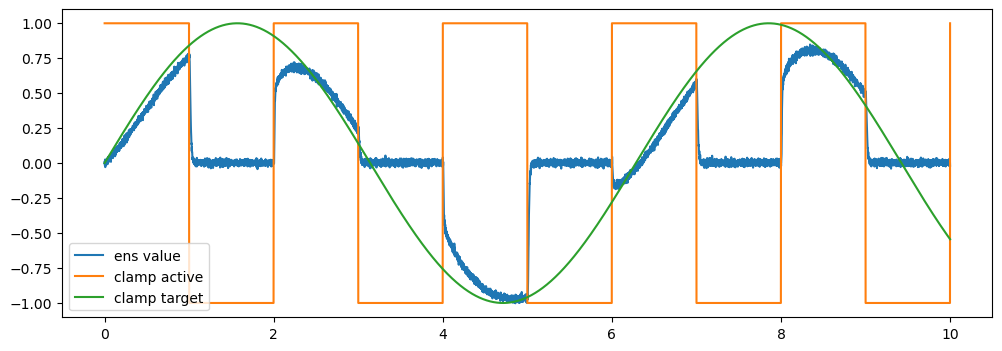

In [4]:
plt.figure(figsize=(12,4))
plt.plot(sim.trange(), sim.data[p_ens], label='ens value')
plt.plot(sim.trange(), sim.data[p_active], label='clamp active')
plt.plot(sim.trange(), sim.data[p_target], label='clamp target')
plt.legend()
plt.show()


Now let's make a really simple system with two values being represented: `x` and `y`.  Either one can be clamped.  For this example, let's add a really simple relationship between `x` and `y`:  we'll just say that $y=-x$.  We implement this with Connections between `x` and `y`.

In [5]:
model = nengo.Network()
with model:
    x = nengo.Ensemble(n_neurons=100, dimensions=1)
    clamp_x = Clamp(size_in=1)
    nengo.Connection(x, clamp_x.actual)
    nengo.Connection(clamp_x.output, x)

    stim_active_x = nengo.Node(lambda t: 1 if t<5 else -1)
    stim_target_x = nengo.Node(lambda t: np.sin(t))
    nengo.Connection(stim_active_x, clamp_x.active)
    nengo.Connection(stim_target_x, clamp_x.target)
    p_target_x = nengo.Probe(stim_target_x)
    p_active_x = nengo.Probe(stim_active_x)
    p_x = nengo.Probe(x, synapse=0.01)
    

    y = nengo.Ensemble(n_neurons=100, dimensions=1)
    clamp_y = Clamp(size_in=1)
    nengo.Connection(y, clamp_y.actual)
    nengo.Connection(clamp_y.output, y)

    stim_active_y = nengo.Node(lambda t: 1 if 6<t<11 else -1)
    stim_target_y = nengo.Node(lambda t: np.sin(t))
    nengo.Connection(stim_active_y, clamp_y.active)
    nengo.Connection(stim_target_y, clamp_y.target)
    p_target_y = nengo.Probe(stim_target_y)
    p_active_y = nengo.Probe(stim_active_y)
    p_y = nengo.Probe(y, synapse=0.01)


    # define the relationship between x and y
    nengo.Connection(x, y, transform=-1)
    nengo.Connection(y, x, transform=-1)
    

sim = nengo.Simulator(model)
with sim:
    sim.run(20)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

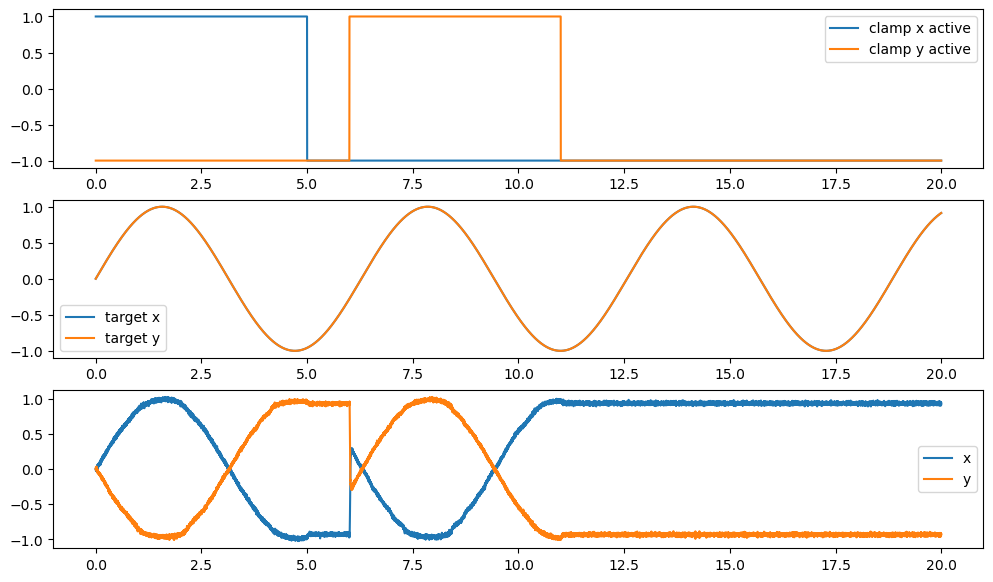

In [6]:
plt.figure(figsize=(12,7))
plt.subplot(3, 1, 1)
plt.plot(sim.trange(), sim.data[p_active_x], label='clamp x active')
plt.plot(sim.trange(), sim.data[p_active_y], label='clamp y active')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(sim.trange(), sim.data[p_target_x], label='target x')
plt.plot(sim.trange(), sim.data[p_target_y], label='target y')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(sim.trange(), sim.data[p_x], label='x')
plt.plot(sim.trange(), sim.data[p_y], label='y')
plt.legend()
plt.show()


This works!  When clamp x is active, x follows the target and y gets the negative of the target.  When clamp y is active, y follows the target and x is the negative.  Also, note that when neither clamp is active, the system just maintains its existing state, thanks to the two mutual Connections between the Ensembles.

However, this is a really simple relationship between variables.  What about a relationship that's a bit more complicated?

Let's do one of the XOR-like category examples.  Let's have x be two-dimensional and y is one-dimensional, where y is a category label, and x has some separated clusters.  First let's create the dataset

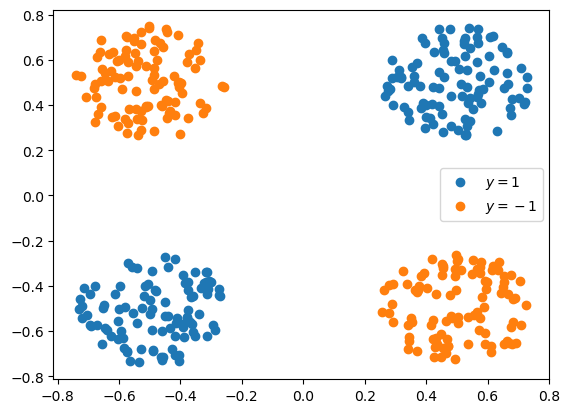

In [7]:
x_pts = []
y_pts = []
x_pts.extend(nengo.dists.UniformHypersphere(surface=False).sample(d=2, n=100)*0.25+[0.5,0.5])
y_pts.extend(np.ones(100))
x_pts.extend(nengo.dists.UniformHypersphere(surface=False).sample(d=2, n=100)*0.25+[-0.5,-0.5])
y_pts.extend(np.ones(100))
x_pts.extend(nengo.dists.UniformHypersphere(surface=False).sample(d=2, n=100)*0.25+[-0.5,+0.5])
y_pts.extend(-np.ones(100))
x_pts.extend(nengo.dists.UniformHypersphere(surface=False).sample(d=2, n=100)*0.25+[+0.5,-0.5])
y_pts.extend(-np.ones(100))
x_pts = np.array(x_pts)
y_pts = np.array(y_pts)

plt.scatter(x_pts[y_pts==1,0], x_pts[y_pts==1,1], label='$y=1$')
plt.scatter(x_pts[y_pts==-1,0], x_pts[y_pts==-1,1], label='$y=-1$')
plt.legend()
plt.show()

Let's start with the separate clamps and the neurons they control for `x` and `y`.

In [8]:
model = nengo.Network()
with model:
    clamp_x0 = Clamp(size_in=1)
    clamp_x1 = Clamp(size_in=1)
    clamp_y = Clamp(size_in=1)
    
    x = nengo.Ensemble(n_neurons=100, dimensions=2)
    y = nengo.Ensemble(n_neurons=50, dimensions=1)
    
    nengo.Connection(x[0], clamp_x0.actual)
    nengo.Connection(clamp_x0.output, x[0])
    nengo.Connection(x[1], clamp_x1.actual)
    nengo.Connection(clamp_x1.output, x[1])
    
    nengo.Connection(y, clamp_y.actual)
    nengo.Connection(clamp_y.output, y)


Now, instead of directly connecting `x` and `y`, let's make an intermediate population that represents both x and y.  We then add a recurrent connection to that intermediate population that will push it towards any datapoint in the training set.  We'll do this by just defining a function where we take the input (x,y) value, find the closest value in the dataet, and then return the delta.  Note that this is just doing a standard NEF differential equation implementation for the recurrent connection, but we don't need to include the $+I$ term because that's already taken care of by the mutual connections between the two populations. 

Note that in order to get this to work I had to add a scaling factor on the distance in the `y` dimension.  It makes sense that there is a parameter there, since we're computing a some "distance" measure and `x` and `y` aren't in the same space.  But I couldn't figure out a good way of picking that parameter (something to do with the variance in the space?).  So I'm just setting it to a value that works for now.

In [9]:
with model:
    mix = nengo.Ensemble(n_neurons=3000, dimensions=3, radius=2)
    nengo.Connection(x, mix[:2])
    nengo.Connection(y, mix[2:])
    nengo.Connection(mix[:2],x)
    nengo.Connection(mix[2:],y)

    def relate(x):
        # find the closest point in the dataset
        # Note: Not sure why a scaling factor of 0.2 is needed on y
        dists = (x[0]-x_pts[:,0])**2 + (x[1]-x_pts[:,1])**2 + 0.2*(x[2]-y_pts)**2
        index = np.argmin(dists)
        # move towards that datapoint
        return x_pts[index,0]-x[0], x_pts[index,1]-x[1], y_pts[index]-x[2]
    Km=5  # control for how hard to push towards the dataset manifold
    nengo.Connection(mix, mix, function=relate, transform=0.1*Km, synapse=0.1)


Now let's try this model out.  We'll start by using it as a classifier: clamp both dimensions of `x` and see what `y` does.

In [10]:
model2 = nengo.Network()
with model2:
    model2.networks.append(model)


    clamp_x = nengo.Node(1)
    nengo.Connection(clamp_x, clamp_x0.active)
    nengo.Connection(clamp_x, clamp_x1.active)
    
    stim_target_x0 = nengo.Node(lambda t: 1 if t%1<0.5 else -1)
    stim_target_x1 = nengo.Node(lambda t: 1 if t%2<1 else -1)
    nengo.Connection(stim_target_x0, clamp_x0.target)
    nengo.Connection(stim_target_x1, clamp_x1.target)

    p_y = nengo.Probe(y, synapse=0.01)
    p_x = nengo.Probe(x, synapse=0.01)

sim = nengo.Simulator(model2)
with sim:
    sim.run(4)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

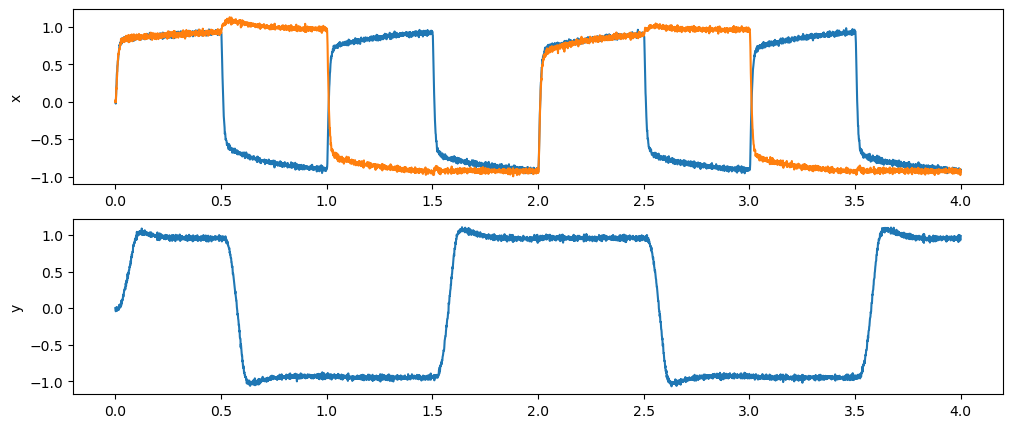

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(2, 1, 1)
plt.plot(sim.trange(), sim.data[p_x])
plt.ylabel('x')
plt.subplot(2, 1, 2)
plt.plot(sim.trange(), sim.data[p_y])
plt.ylabel('y')
plt.show()

It is correctly classifying the inputs based on the training data.

Now let's try clamping y and one of the two x values.  That should cause the other x value to go to its correct value.

In [12]:
model2 = nengo.Network()
with model2:
    model2.networks.append(model)

    clamp = nengo.Node(1)
    nengo.Connection(clamp, clamp_x0.active)
    nengo.Connection(clamp, clamp_y.active)
    
    stim_target_y = nengo.Node(lambda t: 1 if t%1<0.5 else -1)
    stim_target_x0 = nengo.Node(lambda t: 0.5 if t%2<1 else -0.5)
    nengo.Connection(stim_target_y, clamp_y.target)
    nengo.Connection(stim_target_x0, clamp_x0.target)

    p_y = nengo.Probe(y, synapse=0.01)
    p_x = nengo.Probe(x, synapse=0.01)

sim = nengo.Simulator(model2)
with sim:
    sim.run(4)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

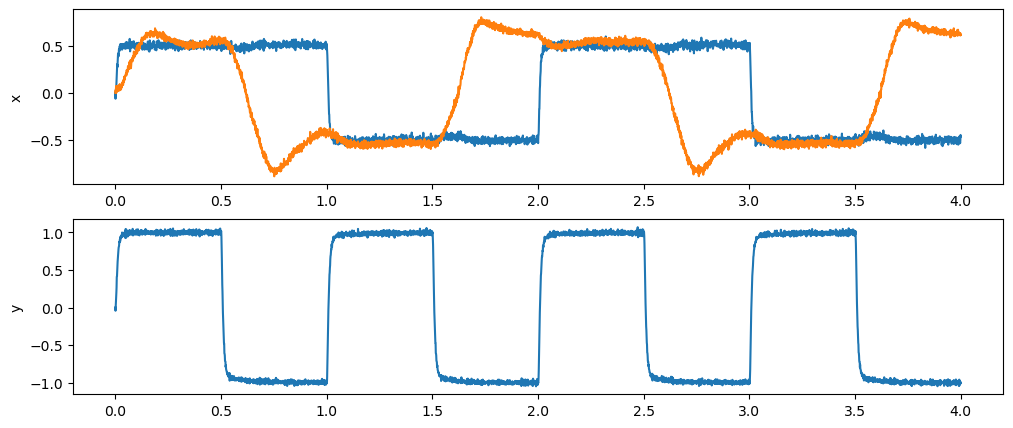

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(2, 1, 1)
plt.plot(sim.trange(), sim.data[p_x])
plt.ylabel('x')
plt.subplot(2, 1, 2)
plt.plot(sim.trange(), sim.data[p_y])
plt.ylabel('y')
plt.show()

The second dimension of the `x` population correctly goes to the right values when we change `y`.